### Importation des bibliothèques

In [29]:
from pathlib import Path
import sys

project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.preprocessing.data_loader import load_data
from src.utils.anomaly_utils import check_missing_values
from src.visualization.visualization import plot_transaction_types

In [ ]:
import random
np.random.seed(42)
random.seed(42)

### Vue générale des données

#### 1. Chargement des données

In [31]:
df = load_data("C:\\Users\\lenovo\\Desktop\\anomaly_detection_project\\data\\raw\\dataset_orig.csv", sample=True)

#### 2. Informations générales

In [32]:
print("Nombre de lignes et de colonnes du dataframe :")
print("Shape:", df.shape)

Nombre de lignes et de colonnes du dataframe :
Shape: (200000, 11)


#### 3. Exploration des premières lignes du dataset

In [33]:
print("\nAperçu des premières lignes du dataset :")
df.head()


Aperçu des premières lignes du dataset :


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


#### 4. Informations sur le dataframe

In [34]:
print("\nInformations sur le dataframe :")
df.info()


Informations sur le dataframe :
<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            200000 non-null  int64  
 1   type            200000 non-null  str    
 2   amount          200000 non-null  float64
 3   nameOrig        200000 non-null  str    
 4   oldbalanceOrg   200000 non-null  float64
 5   newbalanceOrig  200000 non-null  float64
 6   nameDest        200000 non-null  str    
 7   oldbalanceDest  200000 non-null  float64
 8   newbalanceDest  200000 non-null  float64
 9   isFraud         200000 non-null  int64  
 10  isFlaggedFraud  200000 non-null  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 16.8 MB


#### 5. Statistiques descriptives

In [35]:
print("\nStatistiques descriptives :")
df.describe()


Statistiques descriptives :


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,200000.00000,2.000000e+05,2.000000e+05,2.000000e+05,2.000000e+05,2.000000e+05,200000.000000,200000.0
mean,10.06589,1.808112e+05,8.821957e+05,9.001938e+05,9.411592e+05,1.191866e+06,0.000735,0.0
std,2.12174,3.291800e+05,2.766264e+06,2.803759e+06,2.373010e+06,2.655236e+06,0.027101,0.0
min,1.00000,3.200000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
25%,9.00000,1.201612e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
50%,10.00000,6.872104e+04,1.951000e+04,0.000000e+00,5.055850e+04,1.320839e+05,0.000000,0.0
75%,12.00000,2.290791e+05,1.915686e+05,2.275212e+05,7.645361e+05,1.189164e+06,0.000000,0.0
max,13.00000,1.000000e+07,3.893942e+07,3.894623e+07,3.903958e+07,3.904248e+07,1.000000,0.0


#### 6. Vérification des types de données

In [36]:
print("\nTypes de données des colonnes :")
print(df.dtypes)


Types de données des colonnes :
step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object


#### 7. Vérification des valeurs manquantes et les doublons

In [54]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
hour              0
night_activity    0
dtype: int64

In [37]:
check_missing_values(df)

,Missing Values,Percentage
step,0,0.0
type,0,0.0
amount,0,0.0
nameOrig,0,0.0
oldbalanceOrg,0,0.0
newbalanceOrig,0,0.0
nameDest,0,0.0
oldbalanceDest,0,0.0
newbalanceDest,0,0.0
isFraud,0,0.0


In [38]:
print("\nNombre de duplicates :", df.duplicated().sum())


Nombre de duplicates : 0


#### 8. Analyse du déséquilibre

In [39]:
fraud_distribution = df["isFraud"].value_counts(normalize=True) * 100
print(fraud_distribution)

isFraud
0    99.9265
1     0.0735
Name: proportion, dtype: float64


In [57]:
fraud_counts = df["isFraud"].value_counts()
fraud_ratio = fraud_counts[0] / fraud_counts[1]

print("Fraud percentage:", df["isFraud"].mean() * 100)
print("Imbalance ratio (NonFraud/Fraud):", fraud_ratio)

Fraud percentage: 0.0735
Imbalance ratio (NonFraud/Fraud): 1359.544217687075


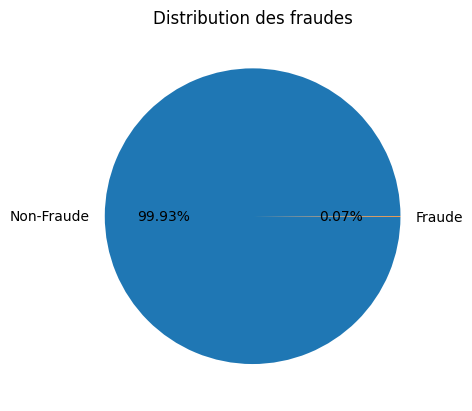

In [40]:
fraud_distribution.plot(kind='pie', autopct='%1.2f%%', labels=['Non-Fraude', 'Fraude'])
plt.title('Distribution des fraudes')
plt.show()

#### ATTENTION :
##### commenter fraude et non fraude et expliquer pourquoi recall sera prioritaire

#### ATTENTION :
##### Fraude (1) : Transactions malveillantes visant à vider les comptes (per Kaggle).
##### Non-fraude (0) : Transactions normales.
##### Recall prioritaire : Dans la détection de fraudes, minimiser les faux négatifs (fraudes manquées) est critique, car coûteux. Accuracy trompeuse due à l'imbalance ; focus sur F1/PR-curve.

#### 9. Distribution des types de transaction

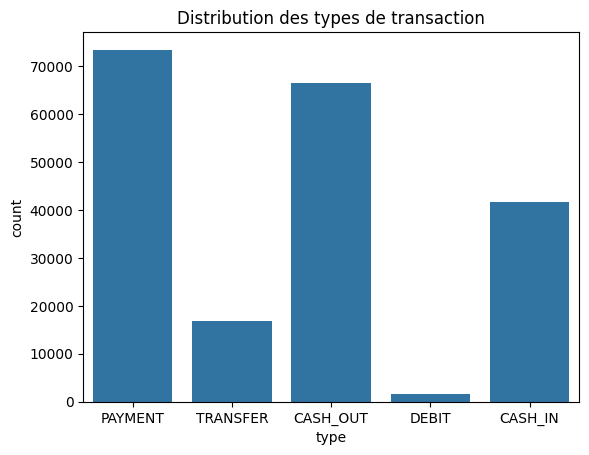

In [41]:
sns.countplot(x='type', data=df)
plt.title('Distribution des types de transaction')
plt.show()

#### 10. Distribution des montants

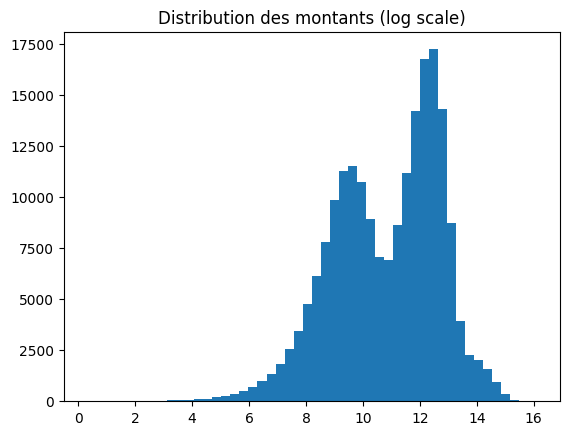

In [42]:
plt.hist(np.log1p(df["amount"]), bins=50)
plt.title("Distribution des montants (log scale)")
plt.show()

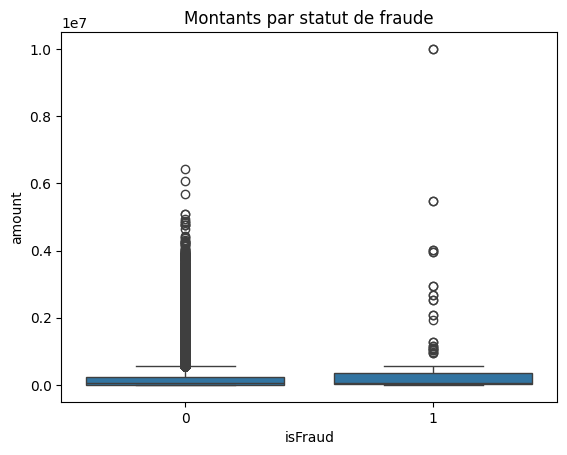

In [43]:
sns.boxplot(x='isFraud', y='amount', data=df)
plt.title('Montants par statut de fraude')
plt.show()
# Insight : Outliers plus élevés en fraudes ?

#### ATTENTION :
##### * pourquoi log scale 
##### * Les montants sont très asymétriques.
##### -> je dois analyser : présence d'outliers + queue longue

#### 11. Fraude par type de transaction

In [44]:
fraud_by_type = pd.crosstab(df["type"], df["isFraud"], normalize="index") * 100
print(fraud_by_type)

isFraud            0         1
type                          
CASH_IN   100.000000  0.000000
CASH_OUT   99.887198  0.112802
DEBIT     100.000000  0.000000
PAYMENT   100.000000  0.000000
TRANSFER   99.572345  0.427655


#### ATTENTION :
##### objectif : Identifier si la fraude est concentrée sur : TRNSFER ou CASH_OUT

#### 12. Analyse temporelle

In [45]:
#création de l'heure réelle :
df["hour"] = df["step"] % 24

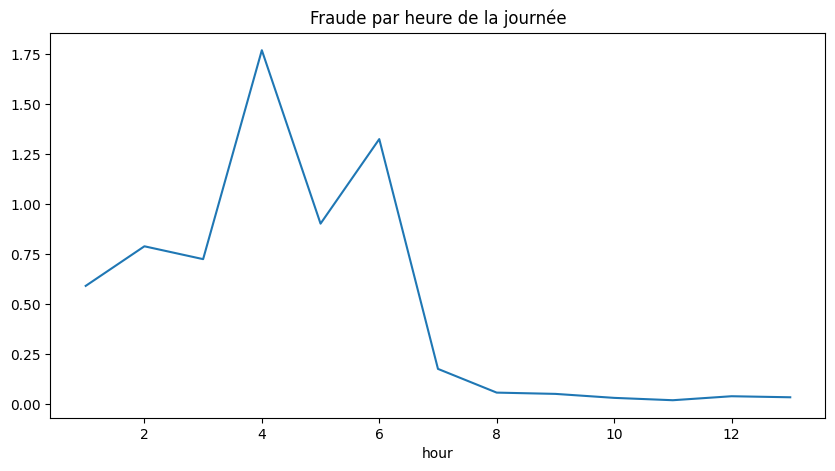

In [60]:
fraud_hour = df.groupby("hour")["isFraud"].mean() * 100
volume_hour = df.groupby("hour")["isFraud"].count()

plt.figure(figsize=(10,5))
fraud_hour.plot()
plt.title("Fraude par heure de la journée")
plt.show()

In [61]:
# Analyse fraude par client

fraud_by_client = df.groupby("nameOrig")["isFraud"].sum()

print("Number of clients involved in fraud:", (fraud_by_client > 0).sum())

Number of clients involved in fraud: 147


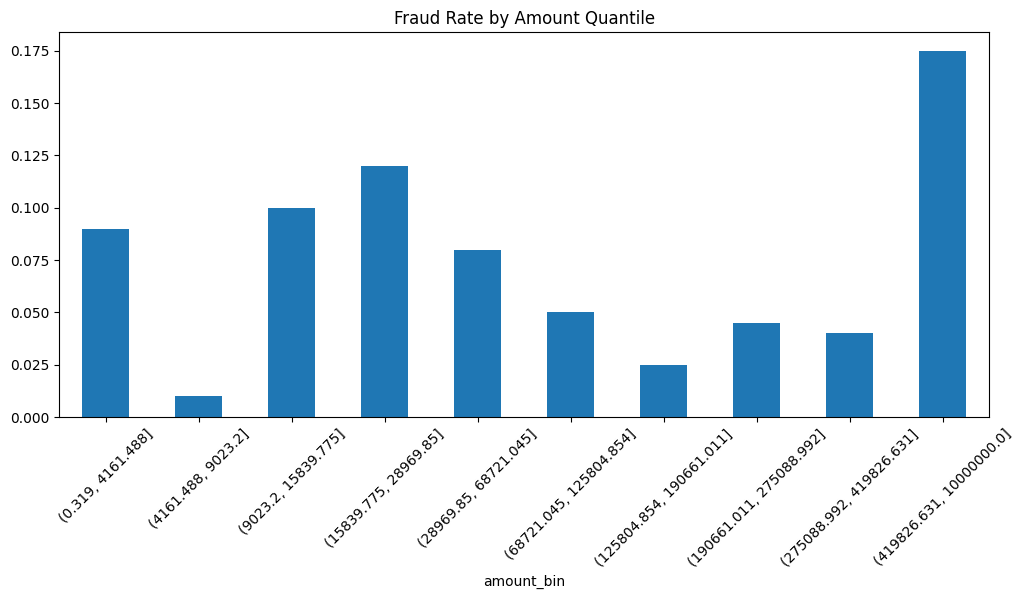

In [58]:
# Distribution fraude par tranche de montant

df["amount_bin"] = pd.qcut(df["amount"], q=10)

fraud_by_amount = df.groupby("amount_bin")["isFraud"].mean() * 100
fraud_by_amount.plot(kind="bar", figsize=(12,5))
plt.title("Fraud Rate by Amount Quantile")
plt.xticks(rotation=45)
plt.show()


Distribution night_activity :
 night_activity
False    97.248
True      2.752
Name: proportion, dtype: float64


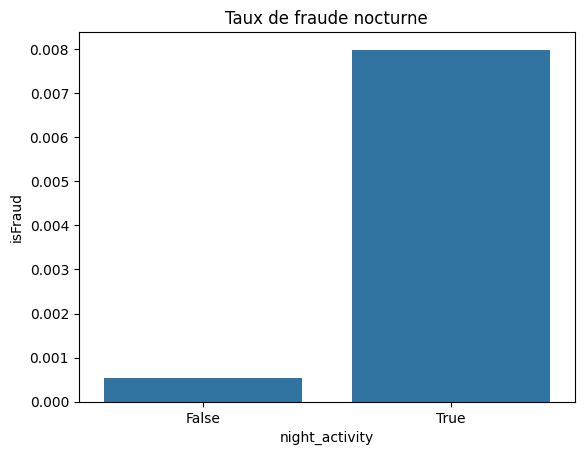

In [47]:
df['night_activity'] = df['hour'].isin([22,23,0,1,2,3,4,5])  # Exemple : 22h-5h
print("\nDistribution night_activity :\n", df['night_activity'].value_counts(normalize=True) * 100)
sns.barplot(x='night_activity', y='isFraud', data=df.groupby('night_activity')['isFraud'].mean().reset_index())
plt.title('Taux de fraude nocturne')
plt.show()

#### ATTENTION :
##### Objectif : Détecter activité nocturne suspecte (fraudes plus probables la nuit).
##### Justification feature "night_activity" : Basé sur patterns temporels ; utile pour DL (input) et LLM (explications comme "transaction à 3h du matin inhabituelle").

#### 13. Vérification du Data Leakage

In [ ]:
correlation = df[[
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "isFraud"
]].corr()

In [49]:
print(correlation["isFraud"])

oldbalanceOrg    -0.002482
newbalanceOrig   -0.008486
oldbalanceDest   -0.008236
newbalanceDest   -0.005162
isFraud           1.000000
Name: isFraud, dtype: float64


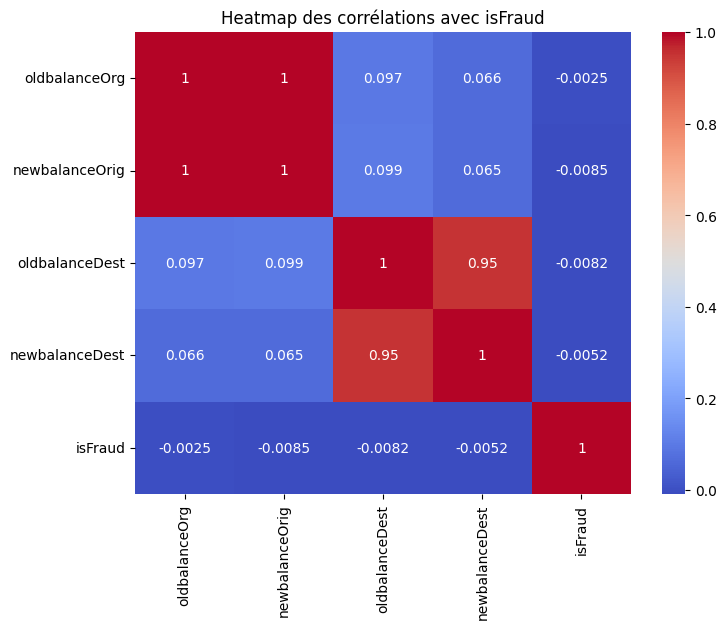

In [56]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Heatmap des corrélations avec isFraud")
plt.show()

#### ATTENTION :
##### Si corrélation très forte → fuite d'information
##### Tu dois expliquer dans ton rapport pourquoi ces colonnes seront exclues.

#### ATTENTION :
##### Corrélations faibles : Pas de leakage évident.
##### Explication dans rapport : Exclure old/newbalance* car transactions frauduleuses annulées (per Kaggle note), risque de bias futur (modèle ne voit pas balances post-fraude en prod).

#### 14. Sauvegarde d’un rapport exploratoire

In [51]:
df.describe().to_csv("C:\\Users\\lenovo\\Desktop\\anomaly_detection_project\\outputs\\reports\\eda_summary.csv")